# Try Codespace Recovery

In [1]:
using Revise
using Latexify
using StatsBase
using Plots
using Plots.Measures

includet("../julia/src/DecoKiller.jl")
includet("../julia/src/utils.jl")
# Utility function for plotting
includet("../julia/src/custom_plots.jl")

# ENV["JULIA_DEBUG"] = "DecoKiller"

using .DecoKiller

In [7]:
cfg, state, logs = load_configuration("../configs/config.toml")

@info "Real noise: " cfg.real_noise.name
@info "Current choice of noise: " state.choice.current
@info "Reference recovery state σ:" cfg.sigma
@info "Starting state:" state.ρ0

# Ensure we are using valid, not-pure, states
@info "Trace: " tr(cfg.sigma)
@info "Purity: " tr(cfg.sigma * cfg.sigma)
@info "Trace: " tr(state.ρ0)
@info "Purity: " tr(state.ρ0 * state.ρ0)

Using specified real noise from config...


┌ Info: Real noise: 
└   cfg.real_noise.name = "bitflip"
┌ Info: Current choice of noise: 
└   state.choice.current = 2
┌ Info: Reference recovery state σ:
│   cfg.sigma =
│    8×8 Matrix{ComplexF64}:
│     0.5+0.0im         0.0+0.0im  …         0.0+0.0im  0.0+0.0im
│     0.0-0.0im  5.62676e-8+0.0im            0.0+0.0im  0.0+0.0im
│     0.0-0.0im         0.0-0.0im            0.0+0.0im  0.0+0.0im
│     0.0-0.0im         0.0-0.0im            0.0+0.0im  0.0+0.0im
│     0.0-0.0im         0.0-0.0im            0.0+0.0im  0.0+0.0im
│     0.0-0.0im         0.0-0.0im  …         0.0+0.0im  0.0+0.0im
│     0.0-0.0im         0.0-0.0im     5.62676e-8+0.0im  0.0+0.0im
└     0.0-0.0im         0.0-0.0im            0.0-0.0im  0.5+0.0im
┌ Info: Starting state:
│   state.ρ0 =
│    8×8 Matrix{ComplexF64}:
│     0.538583+0.0im              0.0+0.0im  …  0.162464-0.103781im
│          0.0+0.0im       2.81338e-8+0.0im          0.0+0.0im
│          0.0+0.0im              0.0+0.0im          0.0+0.0im
│        

Using specified real noise from config...






Adaptive Recovery   2%|▋                                |  ETA: 0:00:18

Adaptive Recovery   3%|█                                |  ETA: 0:00:17

Adaptive Recovery   4%|█▍                               |  ETA: 0:00:16

Adaptive Recovery   5%|█▋                               |  ETA: 0:00:15

Adaptive Recovery   6%|██                               |  ETA: 0:00:15

Adaptive Recovery   7%|██▎                              |  ETA: 0:00:15

Adaptive Recovery   8%|██▋                              |  ETA: 0:00:14

Adaptive Recovery   9%|███                              |  ETA: 0:00:14

Adaptive Recovery  10%|███▎                             |  ETA: 0:00:14

Adaptive Recovery  11%|███▋                             |  ETA: 0:00:14

Adaptive Recovery  12%|████                             |  ETA: 0:00:14

Adaptive Recovery  13%|████▎                            |  ETA: 0:00:13

Adaptive Recovery  14%|████▋                            |  ETA: 0:00:13

Adaptive Recovery  15%|█████                   

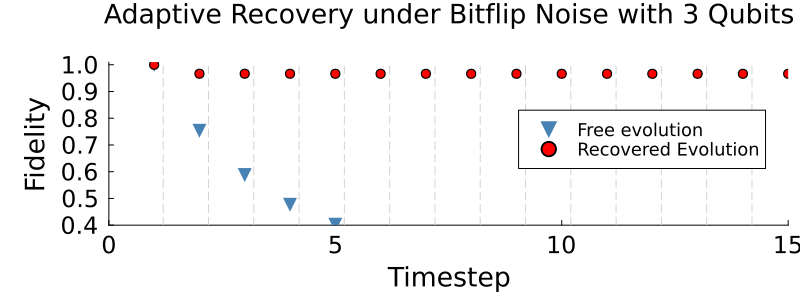

In [8]:
cfg, state, logs, avg_fidelities = run_experiment("../configs/config.toml");
# The output vector shows the fidelities of the recovered state and the free state
g1 = plot_average_fidelity(
	avg_fidelities[2], avg_fidelities[1], state, cfg;
	ylims=[0.4,1.01], size=(800, 300),
	save=false, show=false, legend=:right,
)

## Encoded Fidelities
To compute the fidelities of the Encoded States inside the starting states of the experiment, we need to run manually the outer loop over the states (since these are created randomly)

In [27]:
cfg, state, logs = load_configuration("../configs/config.toml")
@info :seed cfg.seed
@info cfg.rng
for s in 1:5
    @info rand(cfg.rng)
end

Using specified real noise from config...


┌ Info: seed
└   cfg.seed = 324345
[ Info: Random.Xoshiro(0xdfbda79736f853bc, 0xe1eb714ea59ee8b7, 0x4faa62286813fac4, 0xe6b7e843ab2da220, 0xc6caf834c66ac3d3)
[ Info: 0.8014942747880537
[ Info: 0.6085045914450553
[ Info: 0.5443837725163623
[ Info: 0.7481823507805209
[ Info: 0.808666819482834


In [61]:
cfg, state, logs = load_configuration("../configs/config.toml")
    
ref_fidelities = zeros(Float64, cfg.n_timesteps)
fidelities = zeros(Float64, cfg.n_timesteps)

# Encoded codespace setup
g0 = [0.0 + 0.0im; 1.0]
e1 = [1.0 + 0.0im; 0.0]

ggg = foldl(kron, [g0 for _ in 1:cfg.n_qubits])
eee = foldl(kron, [e1 for _ in 1:cfg.n_qubits])
encoded_fidelities = zeros(Float64, cfg.n_timesteps)
projector = ggg * ggg' + eee * eee'  # Projector onto the codespace

for s in 1:cfg.n_states
	initial_state = deepcopy(state)  # Reset state for each run
	reset_initial_state!(initial_state, cfg)

	# Project the initial state onto the codespace
	encoded_ρ0 = projector * initial_state.ρ0 * projector'  
	encoded_ρ0 = encoded_ρ0 / tr(encoded_ρ0)  # Normalize
	f_enc = []
	for step in 1:cfg.n_timesteps
		step_recovery!(step, initial_state, cfg, logs)
		N = logs.maps[end].Nx
		rho = unvec(N * vec(initial_state.ρ0))
		rho = projector * rho * projector'
		rho = rho / tr(rho)
		fid = fidelity(rho, encoded_ρ0)
		push!(f_enc, fid)
	end
	start_state_results = (s - 1) * cfg.n_timesteps + 1
	end_state_results = s * cfg.n_timesteps

	ref_fidelities .+= logs.ref_fidelities[start_state_results:end_state_results]
	fidelities .+= logs.fidelities[start_state_results:end_state_results]
	encoded_fidelities .+= f_enc
end
avg_ref_f = ref_fidelities ./ cfg.n_states
avg_f = fidelities ./ cfg.n_states
avg_enc_f = encoded_fidelities ./ cfg.n_states
avg_fidelities = avg_ref_f, avg_f, avg_enc_f

mean(avg_enc_f)

Using specified real noise from config...


0.9385592320468041

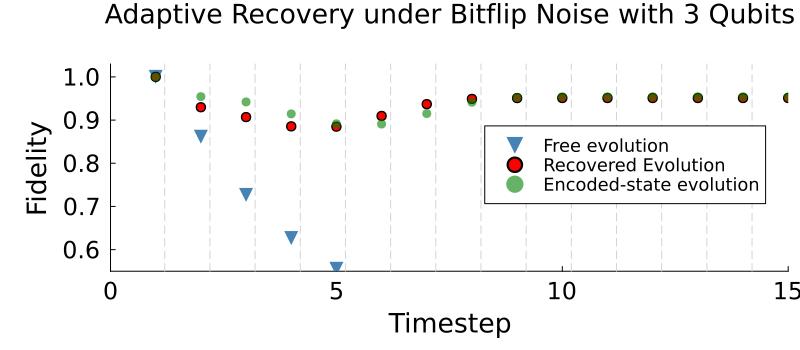

In [62]:
g1 = plot_average_fidelity(
	avg_fidelities[2], avg_fidelities[1], state, cfg;
	ylims=[0.4,1.01], size=(800, 350),
	save=false, show=false, legend=:right,
)
scatter!(
	[1.0; avg_enc_f],
	labels="Encoded-state evolution",
	shape=:circle,
	markercolor=:green,
	markerstrokecolor=:transparent,
	markerstrokewidth=0, 
	markersize=5,
	markeralpha=0.6,
)
ylims!(0.55, 1.03)

savefig(g1, "../experiments/$(cfg.name)/visualization/avg_fidelity_encoded_state.pdf")
g1